## 회귀 예측

In [1]:
import tensorflow as tf                             # 딥러닝 모델 생성을 위한 텐서플로우 라이브러리 호출
from tensorflow.keras import layers, models         # 신경망 레이어와 모델 구성 도구 호출
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from keras.layers import Danse

ImportError: cannot import name 'Danse' from 'keras.layers' (C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\keras\layers\__init__.py)

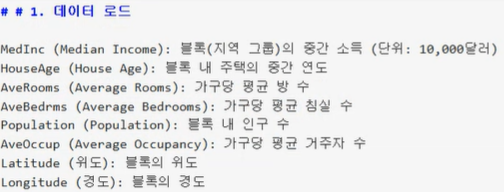

In [2]:
data = fetch_california_housing()
X = data.data
y = data.target

In [3]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [4]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [5]:
# 데이터를 학습용과 테스트용으로 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

# 데이터 정규화 (스케일링)
scaler = standardScaler() #평균 0, 표준편차 1로 변환하기 위한 객체 생성
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [6]:
X_train

array([[   3.2596    ,   33.        ,    5.0176565 , ...,    3.6918138 ,
          32.71      , -117.03      ],
       [   3.8125    ,   49.        ,    4.47354497, ...,    1.73809524,
          33.77      , -118.16      ],
       [   4.1563    ,    4.        ,    5.64583333, ...,    2.72321429,
          34.66      , -120.48      ],
       ...,
       [   2.9344    ,   36.        ,    3.98671727, ...,    3.33206831,
          34.03      , -118.38      ],
       [   5.7192    ,   15.        ,    6.39534884, ...,    3.17889088,
          37.58      , -121.96      ],
       [   2.5755    ,   52.        ,    3.40257649, ...,    2.10869565,
          37.77      , -122.42      ]], shape=(16512, 8))

In [15]:
# 회귀 모델 생성 레루
model = models.Sequential([                                # 시퀸셜 구조로 신경망 모델을 생성
    layers.Dense(64, activation='relu', input_shape=(8,)), # 첫 번째 은닉층 만들고, 64개의 뉴런으로 입력은 8개의 특성이고, relu 활선화 함수 사용
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),                   # 두 번째 은닉층 만들고, 32개의 뉴런으로 학습
    layers.Dropout(0.3),
    layers.Dense(1)                                        # 출력층은 집값처럼 연속값을 예측하기때문에 뉴런 1개로 구성하고, 활성화는 사용하지 않음
])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2778351322.py, line 5)

In [47]:
# 회귀 모델 리키레루
model = models.Sequential([
    layers.Dense(64, input_shape=(8,)),
    layers.Dropout(0.3),
    layers.LeakyReLU(alpha=0.01),
    layers.Dense(32),
    layers.Dropout(0.3),
    layers.LeakyReLU(alpha=0.01),

    layers.Dense(1)
])

C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


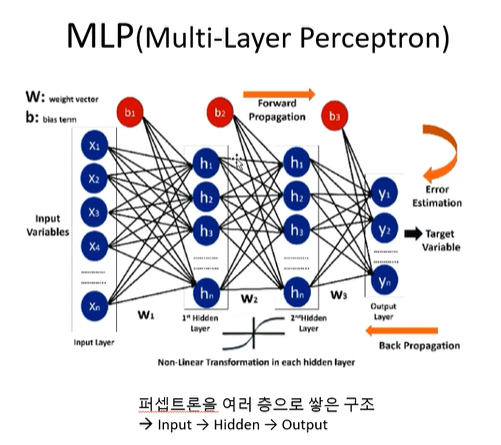

In [8]:
# 모델 설정 (컴파일)
model.compile(
    optimizer = 'adam',   # adam 옵티마이저로 가중치를 효율적으로 업데이트
    loss = 'mse',         # 회귀에서 평균 제곱 오차를 손실 함수로 사용
    metrics=['mae']      # 예측 오차를 확인하기 위해 mas 추가
)

In [9]:
# 모델 학습
history = model.fit(
    X_train, y_train,    # 학습에 사용할 입력과 출력 label 값 넣음
    epochs = 15,
    batch_size= 32,      # 32개의 샘플씩 모델에게 제공해서 가중치 업뎃
    validation_split=0.2 # 학습데이터 80%, 검증데이터 20% 사용해서 과적합 방지 목적
)

Epoch 1/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12462.2256 - mae: 57.6222 - val_loss: 15.1833 - val_mae: 3.5063
Epoch 2/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 435.8298 - mae: 10.6745 - val_loss: 7.9754 - val_mae: 1.7269
Epoch 3/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 177.8382 - mae: 5.8817 - val_loss: 3.3894 - val_mae: 1.2374
Epoch 4/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 111.9587 - mae: 3.7239 - val_loss: 2.9152 - val_mae: 1.2133
Epoch 5/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 34.8724 - mae: 2.6938 - val_loss: 2.8099 - val_mae: 1.1987
Epoch 6/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.2122 - mae: 2.1691 - val_loss: 2.8049 - val_mae: 1.2157
Epoch 7/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.1635 - mae: 1.6243 - val_loss: 2.3329 - val_mae: 1.0879
Epoch 8/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.5759 - mae: 1.4164 - val_loss: 2.0433 - val_mae: 1.0113
Epoch 9/15
413/413 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
# 모델 평가
loss, mae = model.evaluate(X_test, y_test)      # 학습하지 않은 20% 테스트데이터 모델의 성능 평가
print("Test MAE :", mae)                        # mae를 출력해서 실제값과 예측값과의 평균 오차를 확인

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4208 - mae: 0.8787  
Test MAE : 0.8786514401435852


In [13]:
# 예측 수행
pred = model.predict(X_test[:5])    # 테스트 데이터에서 앞 5개를 예측
print("실제값 : ", y_test[:5])      # 실제 집값 출력
print("예측값 : ", pred.reshape(-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
실제값 :  [0.477   0.458   5.00001 2.186   2.78   ]
예측값 :  [1.7291529 1.7564013 1.7641461 1.7614969 1.715176 ]


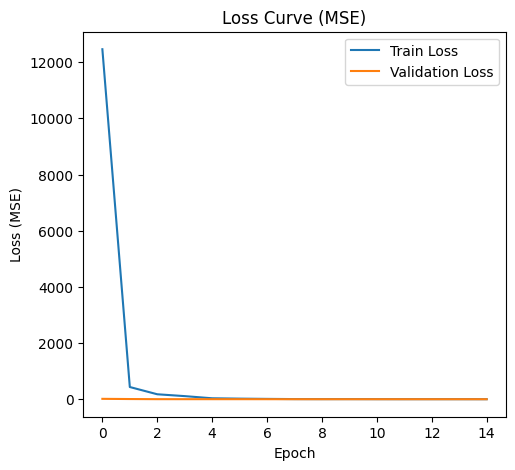

In [16]:
import matplotlib.pyplot as plt

# 학습 시각화 (loss, mae 그래프 생성)
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()

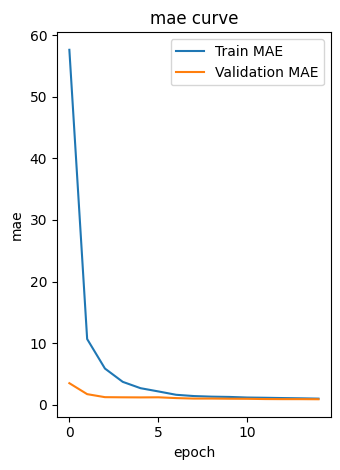

In [14]:
# 학습 / 검증 mae 그래프
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('mae curve')
plt.xlabel('epoch')
plt.ylabel('mae')
plt.legend()

plt.tight_layout()
plt.show()